In [2]:
import pzflow
import optax
from pzflow import Flow
import jax
import jax.numpy as jnp
from pzflow.bijectors import Chain, ShiftBounds, RollingSplineCoupling
from pzflow.distributions import Uniform, CentBeta13
from sklearn.neighbors import KernelDensity

import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from astropy.io import fits
from astropy.table import Table
import astropy.coordinates as coord
from astropy.coordinates import SkyCoord, CartesianRepresentation, CartesianDifferential
import astropy.units as u
from tqdm import tqdm
import seaborn as sns
import pickle
from datetime import datetime, timezone, timedelta
import warnings

import torch
from torch import nn
from torch.nn import Linear, LayerNorm, ReLU
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from torch_geometric.nn import GCNConv, radius_graph, DeepGCNLayer, GENConv, GAT, BatchNorm
from torch_geometric.data import Data
from torch_cluster import knn_graph

from torch_geometric.utils import to_undirected, subgraph
from torch_geometric.transforms import KNNGraph
from torch_geometric.loader import ClusterData, ClusterLoader, DataLoader
import torchvision
from torchvision.ops import sigmoid_focal_loss
from torchmetrics.classification import BinaryMatthewsCorrCoef

import lightning as L
from lightning.pytorch.loggers import WandbLogger
from lightning.pytorch import seed_everything
from lightning.pytorch.callbacks import ModelCheckpoint

import wandb

from sklearn.metrics import recall_score, precision_score, f1_score, roc_curve, roc_auc_score, matthews_corrcoef, confusion_matrix
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.exceptions import UndefinedMetricWarning
from sklearn.metrics import precision_recall_curve, average_precision_score
from sklearn.model_selection import train_test_split

ModuleNotFoundError: No module named 'pzflow'

In [2]:
seed_everything(12345)
warnings.filterwarnings("ignore", category=UndefinedMetricWarning)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)
print()

#Additional Info when using cuda
if device.type == 'cuda':
    print(torch.cuda.get_device_name(0))
print(torch.cuda.get_device_properties(device))    

[rank: 0] Seed set to 12345


Using device: cuda

NVIDIA A100-SXM4-40GB
_CudaDeviceProperties(name='NVIDIA A100-SXM4-40GB', major=8, minor=0, total_memory=40326MB, multi_processor_count=108, uuid=c8888979-7d19-c8da-d957-1f2abe5a44cc, L2_cache_size=40MB)


In [1]:
import importlib
import utils
importlib.reload(utils)

# Re-import the function to reflect changes
from utils import count_parameters, get_mask_splits, DeeperGCN, LitDeepGCN, GaiaDataModule, GaiaDataModuleCustom, GaiaDataModuleGD1, GaiaDataModuleGD1CATHODE

SyntaxError: f-string: unmatched '[' (utils.py, line 540)

## Setting up Data for Cathode
#### 1. First separate data into signal and sideband using pm_ra and 3σ cuts
#### 2. Train flow on sideband data, condition on pm_ra
#### 3. Fit KDE to pm_ra distribution in the signal region
#### 4. Sample N values from $p_{KDE}$(pm_ra)
#### 5. Generate N samples from flow conditioned on the N sampled pm_ra values

In [ ]:
load_data_dir = '/pscratch/sd/p/pratsosa/GD-1_gaia_x_decals_stream_prep.fits'
df = Table.read(load_data_dir)


ra = np.array(df['phi1']).astype('float64')
dec = np.array(df['phi2']).astype('float64')

pm_ra  = np.array(df['pm_phi1']).astype('float64')
pm_dec = np.array(df['pm_phi2']).astype('float64')

pm_ra_error = np.array(df['pmra_error']).astype('float64')
pm_dec_error = np.array(df['pmdec_error']).astype('float64')

gmag  = np.array(df['phot_g_mean_mag'])
color = np.array(df['phot_bp_mean_mag']) - np.array(df['phot_rp_mean_mag'])


gmag0, rmag0, zmag0 = np.array(df['gmag0']), np.array(df['rmag0']), np.array(df['zmag0'])
g_r = gmag0-rmag0
r_z = rmag0-zmag0
g_z = gmag0-zmag0

stream = np.array(df['stream'])

roi = np.array(df['roi'], dtype=bool)
signal_region = np.array(df['signal_region'], dtype=bool)
sideband_region = np.array(df['sideband_region'], dtype=bool)


embeddings = np.column_stack((ra, dec, pm_dec, pm_ra_error, pm_dec_error, gmag, color, rmag0, g_r, r_z))
full_embeddings = np.column_stack((ra, dec, pm_ra, pm_dec, pm_ra_error, pm_dec_error, gmag, color, rmag0, g_r, r_z))

scaler = StandardScaler()
scaler.fit(full_embeddings)

np.sum(signal_region), np.sum(~signal_region)

(np.int64(166503), np.int64(1597656))

In [18]:
source_id = np.array(df['source_id'])

In [ ]:

col_names = ['ra', 'dec', 'pm_ra', 'pm_dec', 'pm_ra_error', 'pm_dec_error', 'gmag', 'color', 'rmag0', 'g_r', 'r_z']

data_col_names = ['ra', 'dec', 'pm_dec', 'pm_ra_error', 'pm_dec_error', 'gmag', 'color', 'rmag0', 'g_r', 'r_z']

cond_col_names = ["pm_ra"]

In [6]:
# Create a mask which masks the .05th and 99.95th percentiles of the pm_ra, pm_dec, color, rmag0, g_r, r_z, in full_embeddings (everything except ra, dec, gmag which are columns 1, 2, 5)
# Logic is that ra and dec don't have extreme outliers, and a cut on gmag has already been applied in data prep
perc_mask = np.ones(full_embeddings.shape[0], dtype=bool)
perc_low = .05
perc_high = 99.95
for i in range(full_embeddings.shape[1]):
    if i in [0, 1, 6]:  # Skip ra, dec, gmag
        continue
    col = full_embeddings[:, i]
    lower_perc = np.percentile(col, perc_low)
    upper_perc = np.percentile(col, perc_high)
    perc_mask &= (col >= lower_perc) & (col <= upper_perc)

embeddings = embeddings[perc_mask]
full_embeddings = full_embeddings[perc_mask]
signal_region = signal_region[perc_mask]
stream = stream[perc_mask]

In [19]:
source_id = source_id[perc_mask]

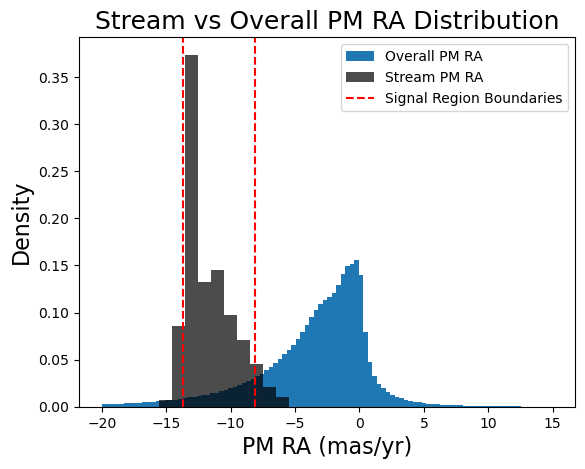

In [7]:
# Shows the stream pm_ra distribution vs overall pm_ra distribution

plt.hist(full_embeddings[:, 2], density=True, bins = 100, range=(-20, 15), label='Overall PM RA')
plt.hist(full_embeddings[stream, 2], density=True, bins=10, color='black', alpha=0.7, label='Stream PM RA')

# Plot the boundaries of the signal region
plt.axvline(x=np.min(full_embeddings[signal_region, 2]), color='r', linestyle='--', label='Signal Region Boundaries')
plt.axvline(x=np.max(full_embeddings[signal_region, 2]), color='r', linestyle='--')
plt.legend()
plt.xlabel('PM RA (mas/yr)', fontsize=16)
plt.ylabel('Density', fontsize=16)
plt.title('Stream vs Overall PM RA Distribution', fontsize=18)
plt.show()

In [8]:
full_embeddings = scaler.transform(full_embeddings)
train_data = full_embeddings[~signal_region]

train_split, test_split = train_test_split(train_data, test_size=0.5, random_state=12345)

df_train = pd.DataFrame(data=train_split, columns = col_names)
df_train_subsampled = df_train.sample(frac=.1, random_state=12345)
df_test = pd.DataFrame(data=test_split, columns = col_names)
df_test_subsampled = df_test.sample(frac = .1, random_state = 12345)

## Flow

In [9]:
data = df_train[data_col_names].values
mins = jnp.array(data.min(axis=0))
maxs = jnp.array(data.max(axis=0))
ndim = data.shape[1]

# Splines are defined on range [-B, B]. I kept the default value of B=5.
B = 5
shift_B = B - 1.0  # map into [-4,4] if B=5 (recommended by pzflow docs)

bijector = Chain(
    ShiftBounds(mins, maxs, B=shift_B), # Does the shifting
    RollingSplineCoupling(nlayers=ndim,  # nlayers: number of (NeuralSplineCoupling(), Roll()) pairs in the chain - default = ndim
                          hidden_layers = 4, # hidden_layers: number of hidden layers used to parametrize each Spline - default = 2
                          hidden_dim = 128, B=B, # hidden_dim: number of neurons in each hidden layer. B: Same as above - default = 128
                          n_conditions = 1, # n_conditions: leave as 1 since we are conditioning on pm_phi1 only
                          K=16) # K: Spline resolution? Paper states "In the limit of high spline resolution (i.e. K → ∞) [...] [flow] can model  model arbitrarily complex distributions"
                                # default = 16
)

# latent = Uniform(input_dim=ndim, B=6)
latent = CentBeta13(input_dim=ndim, B=B) # The default latent space used by pzflow - centered beta distribution with alpha, beta = 13

flow = Flow(data_col_names, bijector=bijector, latent=latent,
            conditional_columns=cond_col_names)

In [ ]:
flow = Flow(data_columns=data_col_names, conditional_columns=cond_col_names)

In [10]:
import optax
# opt = optax.adam(learning_rate=1e-5)
num_epochs = 200
max_lr = 3e-4
batch_size = 512
total_steps = len(df_train) // batch_size * num_epochs
pct_start = 0.3
div_factor = 10
final_div_factor = 1000

# Create the one-cycle schedule function
lr_schedule = optax.cosine_onecycle_schedule(
    peak_value=max_lr,
    transition_steps=total_steps,
    pct_start=pct_start,
    div_factor=div_factor,
    final_div_factor=final_div_factor
)

opt = optax.chain(
    optax.clip_by_global_norm(1.0),  # Gradient clipping
    optax.adam(learning_rate=lr_schedule)   # Very low learning rate
)

In [ ]:
%%time
train_losses, test_losses = flow.train(df_train, df_test, verbose=True, epochs=num_epochs, progress_bar=False, batch_size=batch_size, optimizer=opt)

Training 200 epochs 
Loss:
(0) 44.0378  44.0770
(1) 1.9209  1.9335
(11) -0.7472  -0.7189
(21) -1.2331  -1.1934
(31) -1.2971  -1.2507
(41) -1.5727  -1.5171
(51) -1.6578  -1.5961
(61) -1.9220  -1.8448
(71) -2.1579  -2.0533
(81) -2.0656  -1.9456
(91) -2.2263  -2.0668
(101) -2.2414  -2.0658
(111) -2.0128  -1.8184
(121) -2.4501  -2.2035
(131) -2.4509  -2.1690
(141) -2.5460  -2.2223
(151) -2.6405  -2.2724
(161) -2.6760  -2.2687
(171) -2.7055  -2.2597
(181) -2.7428  -2.2654
(191) -2.7569  -2.2620
(200) -2.7603  -2.2624
CPU times: user 28min 16s, sys: 1min 43s, total: 29min 59s
Wall time: 26min 44s


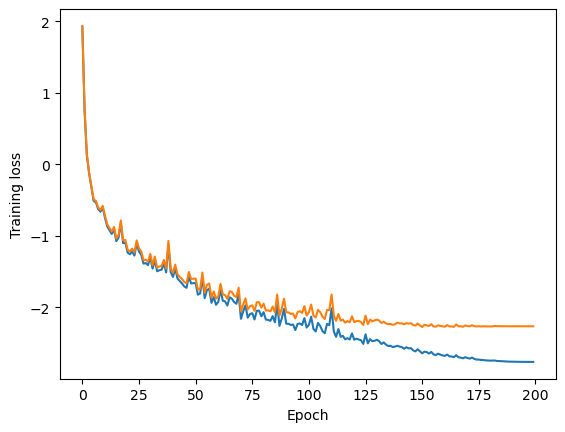

In [12]:
plt.plot(train_losses[1:])
plt.plot(test_losses[1:])
plt.xlabel("Epoch")
plt.ylabel("Training loss")
# plt.ylim(0, 13)
plt.show()


In [14]:
from sklearn.neighbors import KernelDensity
kde_sig = KernelDensity(bandwidth=0.001)
kde_sig.fit(full_embeddings[:, 2][signal_region].reshape(-1, 1))
m_kde_samples = kde_sig.sample(n_samples= 4 * np.sum(signal_region))  # We sample 4x the number of signal region points as recommended in CATHODE paper

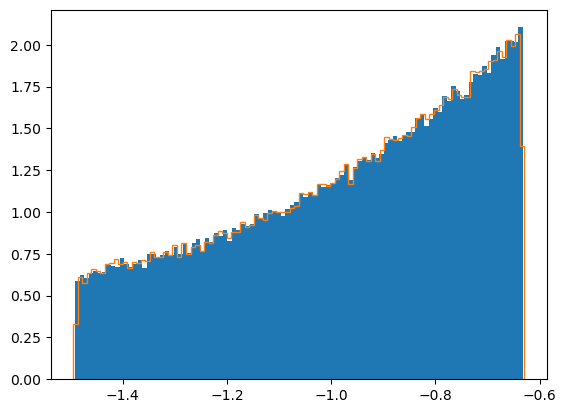

In [15]:
# Quick check that the sampled pm_ra distribution looks similar to the signal region pm_ra distribution

plt.hist(full_embeddings[:, 2][signal_region], bins=100, density=True)
plt.hist(m_kde_samples, bins=100, density=True, histtype='step')
plt.show()

In [16]:
samples_df = flow.sample(nsamples=1, 
                      conditions=pd.DataFrame(data=m_kde_samples.astype('float64'),
                      columns = ["pm_ra"]),
                      save_conditions=True)
# Invert scaling on the samples
samples_df[col_names] = scaler.inverse_transform(samples_df[col_names])
samples_df.head()

,ra,dec,pm_dec,pm_ra_error,pm_dec_error,gmag,color,rmag0,g_r,r_z,pm_ra
0,1.239894,-7.403150,-5.926474,0.231230,0.258470,18.904778,0.692925,18.825956,0.257778,-0.004975,-10.117595
1,46.317169,-6.769003,0.372052,0.214838,0.194388,19.187702,0.795934,19.125786,0.394889,0.161749,-11.957645
2,-10.515981,5.643439,-5.780240,0.125424,0.109815,17.871071,0.767960,17.763927,0.380820,0.110072,-10.196526
3,-14.214531,-2.344404,-9.215747,0.310381,0.244217,18.836929,0.899966,18.702082,0.413965,0.135546,-9.033267
4,51.577015,0.143161,-3.064020,0.111491,0.098928,17.869730,0.867527,17.776352,0.467559,0.174780,-10.209085


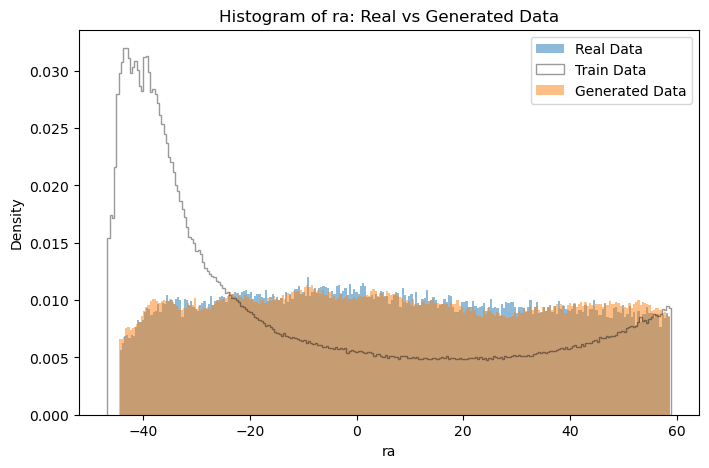

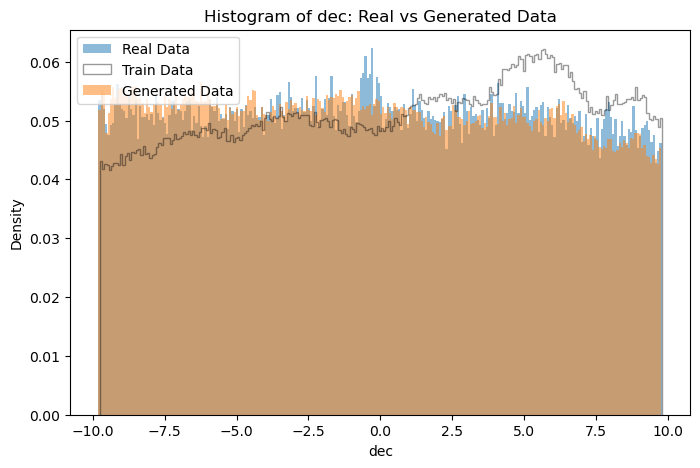

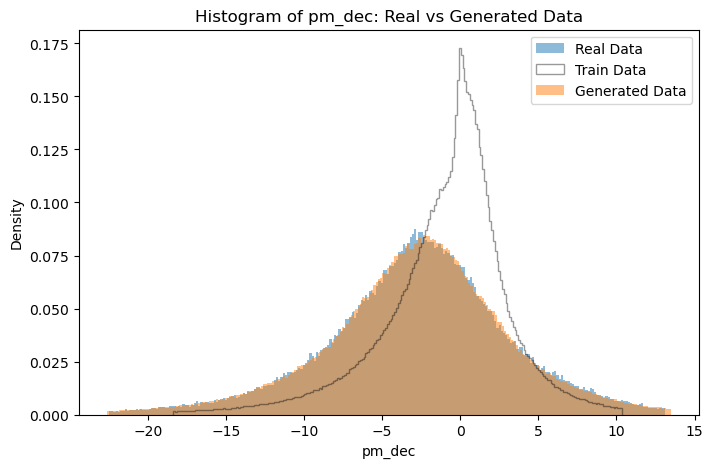

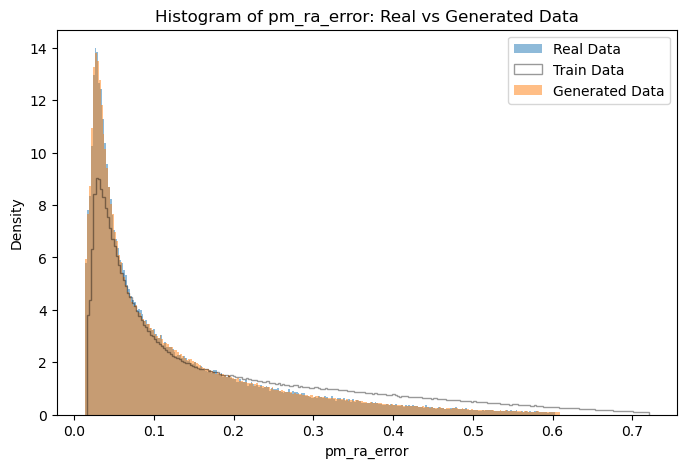

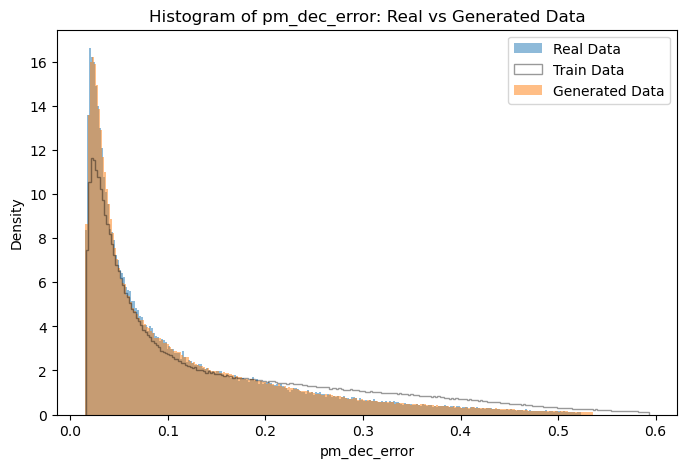

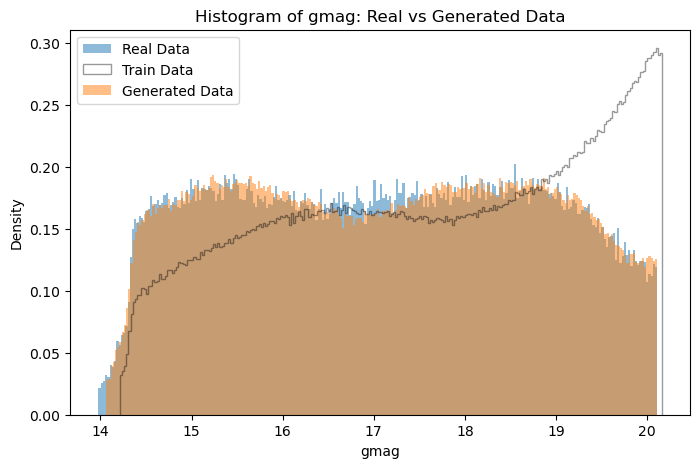

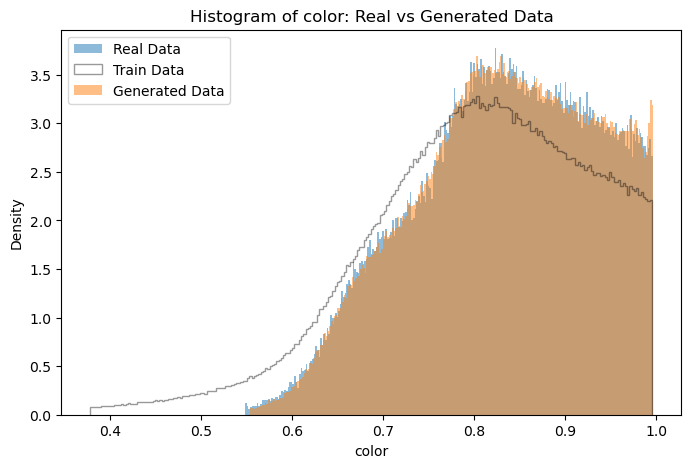

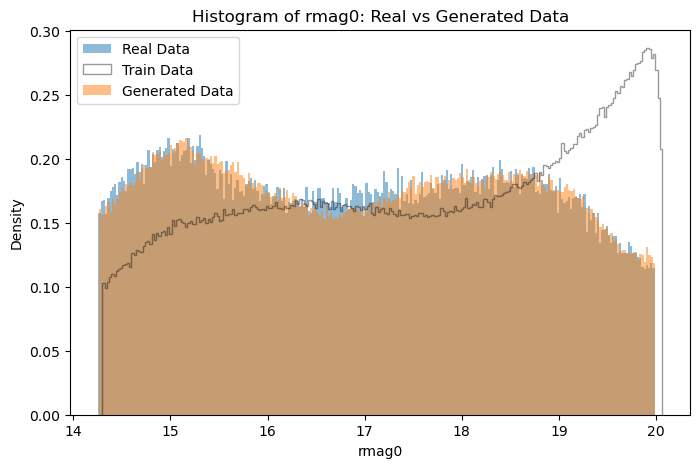

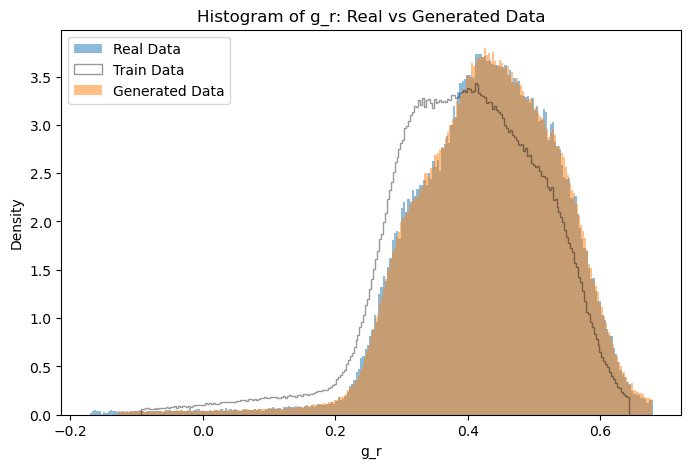

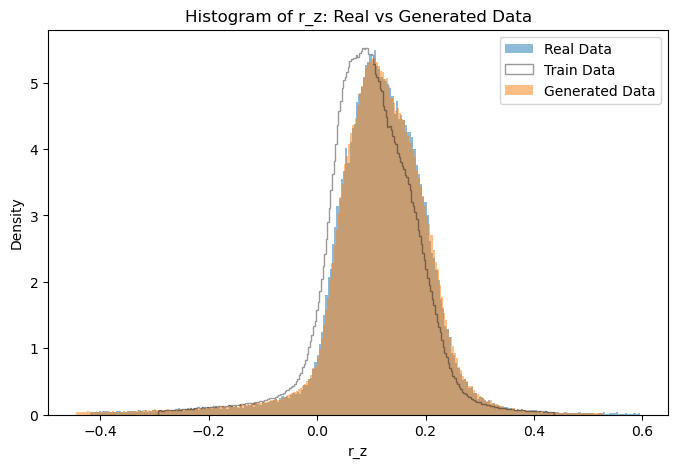

In [17]:
# Print 1D histograms of the generated samples vs the signal region data for each feature
# This shows us how well the flow is interpolating in the signal region
sig_data = embeddings[signal_region]
train_data = embeddings[~signal_region]
sig_generated = samples_df.to_numpy()

for i, col in enumerate(data_col_names):
    plt.figure(figsize=(8,5))
    plt.hist(sig_data[:, i], density=True, bins=250, alpha=0.5, label='Real Data', range=(np.percentile(sig_data[:, i], 1), np.percentile(sig_data[:, i], 99)))
    plt.hist(train_data[:, i], density=True, bins=250, alpha=0.4, label='Train Data', color = 'black', histtype='step',range=(np.percentile(train_data[:, i], 1), np.percentile(train_data[:, i], 99)))
    plt.hist(sig_generated[:, i], density=True, bins=250, alpha=0.5, label='Generated Data', range=(np.percentile(sig_generated[:, i], 1), np.percentile(sig_generated[:, i], 99)))
    plt.xlabel(col)
    plt.ylabel('Density')
    plt.title(f'Histogram of {col}: Real vs Generated Data')
    plt.legend()
    plt.show()

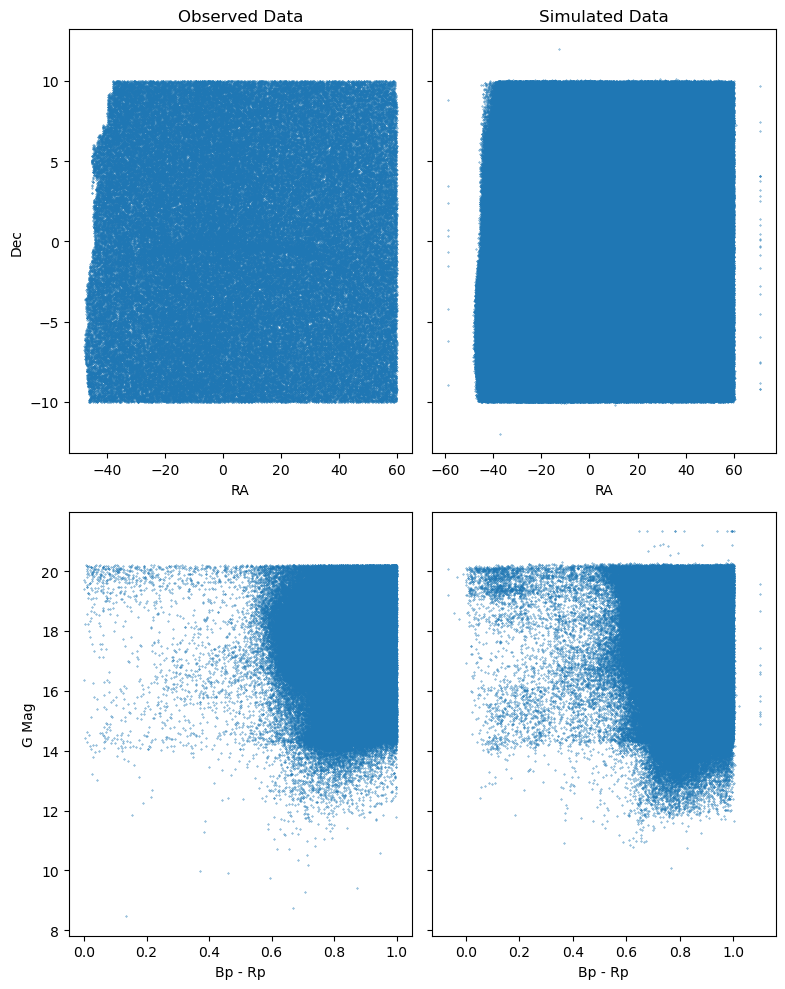

In [37]:
data = embeddings[signal_region]

fig, axs = plt.subplots(2, 2, figsize=(8, 10), sharey='row')

# First row
axs[0, 0].scatter(data[:, 0], data[:, 1], s=0.1)
# axs[0, 0].scatter(data[:, 0][true_labels_test], data[:, 1][true_labels_test], s=1)

axs[0, 1].scatter(samples_df['ra'], samples_df['dec'], s=0.1)
axs[0, 0].set_ylabel("Dec")
axs[0, 0].set_xlabel("RA")
axs[0, 1].set_xlabel("RA")

# axs[0, 1].set_xlim(np.min(data[:, 0]), np.max(data[:, 0]))
# axs[0, 1].set_ylim(np.min(data[:, 1]), np.max(data[:, 1]))


# Second row
axs[1, 0].scatter(data[:, 4], data[:, 3], s=0.1)
# axs[2, 0].scatter(data[:, 5][true_labels_test], data[:, 4][true_labels_test], s=1)

axs[1, 1].scatter(samples_df['color'], samples_df['gmag'], s=0.1)
axs[1, 0].set_ylabel("G Mag")
axs[1, 0].set_xlabel("Bp - Rp")
axs[1, 1].set_xlabel("Bp - Rp")
# axs[2, 1].set_xlim(0.5, 1)

# axs[2, 1].set_ylim(np.min(data[:, 4][true_labels_test]), 20)

# Column titles
axs[0, 0].set_title("Observed Data")
axs[0, 1].set_title("Simulated Data")

# invert the axes for magnitude
axs[1, 0].invert_yaxis()
axs[1, 1].invert_yaxis()


# Optional: remove redundant y-axis labels for the right column
for i in range(2):
    axs[i, 1].tick_params(labelleft=False)

# Adjust layout
fig.tight_layout()
# plt.savefig('Observed_vs_Simulated_Data_PZFlow.png')
plt.show()

In [68]:
samples_df

,ra,dec,pm_dec,gmag,color,g_r,r_z,g_z,parallax,pm_ra
0,39.840786,9.922945,-0.510178,19.844244,0.939419,0.477260,0.163557,0.642796,-0.219578,-8.125716
1,0.554968,-8.559036,-10.159531,15.313511,0.904567,0.510453,0.043806,0.561780,0.652697,-11.660226
2,-44.597183,-4.848290,22.698212,15.761297,0.984498,0.493933,0.173544,0.670452,0.997429,-9.227182
3,8.325986,2.366955,-7.518661,17.621975,0.679023,0.321618,0.027554,0.351759,0.105122,-8.696558
4,3.580389,5.859033,-2.620613,17.683249,0.975412,0.574249,0.165094,0.744940,0.288111,-11.530725
...,...,...,...,...,...,...,...,...,...,...
666007,50.510399,6.406914,0.902176,17.462006,0.717258,0.346827,0.078183,0.428703,0.318954,-10.735640
666008,-12.856983,2.651110,-0.112000,18.169771,0.720452,0.326914,0.068204,0.398050,0.261402,-11.447669
666009,29.586905,-2.237395,-9.663651,18.290459,0.938227,0.496887,0.193645,0.691948,0.305389,-9.254969
666010,6.804051,2.595958,2.044342,17.945673,0.727374,0.354832,0.044117,0.403126,0.216396,-10.690034


In [21]:
full_embeddings = scaler.inverse_transform(full_embeddings)
signal_df = pd.DataFrame(data=full_embeddings[signal_region], columns = col_names)

In [23]:
signal_stream = stream[signal_region]
signal_df['stream'] = signal_stream.astype(int)
signal_df['CWoLa_Label'] = np.ones_like(signal_stream).astype(int)
signal_df['source_id'] = source_id[signal_region]

samples_df['stream'] = np.ones(len(samples_df)).astype(int) * 2
samples_df['CWoLa_Label'] = np.zeros(len(samples_df)).astype(int)
samples_df['source_id'] = np.ones(len(samples_df)) * -1

In [24]:
full_df = pd.concat([signal_df, samples_df], ignore_index=True)
full_df.head()

,ra,dec,pm_ra,pm_dec,pm_ra_error,pm_dec_error,gmag,color,rmag0,g_r,r_z,stream,CWoLa_Label,source_id
0,-36.508754,-8.760049,-8.108584,-4.126551,0.268878,0.157249,18.817284,0.828291,18.675226,0.427288,0.134838,0,1,5.764656e+17
1,-36.481095,-8.770991,-10.776368,3.488612,0.035303,0.021194,14.873737,0.799150,14.742486,0.393524,0.084764,0,1,5.764660e+17
2,-36.425050,-8.791955,-12.471865,-5.437217,0.206568,0.134509,18.497396,0.762947,18.360977,0.376686,0.108385,0,1,5.764677e+17
3,-36.334098,-8.823325,-12.108052,8.235608,0.042188,0.027492,14.600136,0.980023,14.436377,0.552838,0.203154,0,1,5.764684e+17
4,-36.135708,-9.003930,-9.671648,-14.002268,0.046634,0.032213,15.561729,0.822738,15.414046,0.394195,0.096489,0,1,5.764735e+17


In [26]:
full_df.to_csv('GD1_errs_LS_CATHODE_4HL_128_HD_16K_3e4LR_200epochs.csv', index=False)